# Day 30 - Kaggle NLP 实战 - 文本分类

> 目标: 用 NLP 方法做文本分类竞赛
>
> 模拟 Kaggle "Real or Not? Disaster Tweets" 竞赛

---

## Day 29 vs Day 30

```
Day 29: 表格数据 (Titanic)  →  特征工程 + RF/GBDT
Day 30: 文本数据 (Tweets)  →  TF-IDF + 词嵌入 + 神经网络

流程一样, 数据类型不同:
  EDA → 特征工程 → 模型训练 → 调参 → 提交
```

## NLP 分类 pipeline

```
原始文本
  → 清洗 (去停用词/标点/小写)
  → TF-IDF 向量化 或 Word Embeddings
  → 分类器 (LR / Naive Bayes / LSTM / Transformer)
  → 预测
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

print('=' * 40)
print('Day 30 - NLP Kaggle')
print('=' * 40)

Day 30 - NLP Kaggle


## 1. 数据准备

> 模拟灾难推文数据集 (Disaster Tweets)
>
> 任务: 判断推文是否在描述真实的灾难事件

In [3]:
# ============================================
# 构造模拟推文数据
# ============================================

np.random.seed(42)

# 灾难推文关键词
disaster_words = ['earthquake', 'flood', 'fire', 'hurricane', 'tsunami',
                  'explosion', 'wildfire', 'tornado', 'volcano', 'landslide',
                  'evacuation', 'emergency', 'destroyed', 'casualty', 'disaster',
                  'collapse', 'debris', 'rescue', 'aftershock', 'devastating']

# 非灾难推文关键词
non_disaster_words = ['movie', 'game', 'music', 'food', 'party', 'birthday',
                      'vacation', 'weather', 'traffic', 'school', 'work',
                      'dinner', 'weekend', 'shopping', 'sports', 'concert',
                      'holiday', 'fitness', 'fashion', 'recipe']

def generate_tweet(is_disaster):
    words = disaster_words if is_disaster else non_disaster_words
    n_words = np.random.randint(5, 15)
    selected = np.random.choice(words, n_words)
    tweet = ' '.join(selected)
    # 加一些随机修饰
    if np.random.random() > 0.5:
        tweet = 'RT ' + tweet
    if np.random.random() > 0.7:
        tweet = '@user ' + tweet
    if np.random.random() > 0.6:
        tweet = tweet + ' #' + np.random.choice(words)
    if np.random.random() > 0.8:
        tweet = tweet + ' https://t.co/xyz'
    return tweet

n = 800
texts = []
labels = []
for i in range(n):
    label = 1 if i < n // 2 else 0
    texts.append(generate_tweet(label))
    labels.append(label)

# 打乱
idx = np.random.permutation(n)
texts = [texts[i] for i in idx]
labels = [labels[i] for i in idx]

df = pd.DataFrame({'text': texts, 'target': labels})
print(f'数据集: {len(df)} 条推文')
print(f'灾难相关: {sum(labels)} | 非灾难: {n - sum(labels)}')
print()
for i in range(5):
    label = 'DISASTER' if df['target'][i] == 1 else 'NORMAL'
    print(f'[{label}] {df["text"][i][:80]}')

数据集: 800 条推文
灾难相关: 400 | 非灾难: 400

[NORMAL] music game birthday traffic school food music traffic holiday shopping school #f
[NORMAL] @user school fashion music dinner concert holiday vacation
[DISASTER] earthquake rescue destroyed flood volcano flood volcano earthquake
[NORMAL] RT birthday work holiday shopping birthday work dinner weekend food vacation gam
[NORMAL] RT fitness recipe fitness school work holiday recipe concert #game https://t.co/


## 2. 文本清洗

> NLP 的第一步永远是清洗文本

In [4]:
# ============================================
# 文本清洗函数
# ============================================

def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+', '', text)  # 去掉 URL
    text = re.sub(r'@\w+', '', text)          # 去掉 @用户
    text = re.sub(r'#\w+', '', text)          # 去掉 #话题
    text = re.sub(r'rt\s+', '', text)         # 去掉 RT
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['text'].apply(clean_text)

print('清洗前后对比:')
for i in range(3):
    print(f'  Before: {df["text"][i][:70]}')
    print(f'  After:  {df["clean"][i][:70]}')
    print()

清洗前后对比:
  Before: music game birthday traffic school food music traffic holiday shopping
  After:  music game birthday traffic school food music traffic holiday shopping

  Before: @user school fashion music dinner concert holiday vacation
  After:  school fashion music dinner conceholiday vacation

  Before: earthquake rescue destroyed flood volcano flood volcano earthquake
  After:  earthquake rescue destroyed flood volcano flood volcano earthquake



## 3. TF-IDF + 分类器

> TF-IDF = 词频 × 逆文档频率
>
> 简单但强大的文本向量化方法

In [8]:
# ============================================
# TF-IDF + 三种分类器对比 (ngram_range=(1,3))
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    df['clean'], df['target'], test_size=0.2, random_state=42
)

# ⚠️ ngram_range 扩大到 (1,3) 后，max_features 必须同步增大
# 否则大量有用的 unigram 会被低频 trigram 挤出词表
TFIDF_PARAMS = {
    'max_features': 8000,       # 从 2000 → 8000
    'ngram_range': (1, 3),      # ✅ 新增：捕获短语级语义
    'sublinear_tf': True,       # ✅ 推荐开启：对 TF 取 log，抑制高频词主导
}

pipelines = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf', MultinomialNB()),
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf', LogisticRegression(max_iter=1000)),
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf', RandomForestClassifier(n_estimators=100)),
    ]),
}

print(f'{"Model":<22} {"Train Acc":<12} {"Val Acc":<12}')
print('-' * 48)

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_acc = pipe.score(X_train, y_train)
    val_acc = pipe.score(X_val, y_val)
    print(f'{name:<22} {train_acc:<12.4f} {val_acc:<12.4f}')

Model                  Train Acc    Val Acc     
------------------------------------------------
Naive Bayes            1.0000       1.0000      
Logistic Regression    1.0000       1.0000      
Random Forest          1.0000       1.0000      


## 4. 深度学习方法 (简易 Embedding + LSTM)

> 用 PyTorch 搭一个 Embedding + LSTM 文本分类器
>
> 跟 TF-IDF + LR 对比效果

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter

# ============================================
# 构建词表 + 序列化
# ============================================

all_words = ' '.join(df['clean']).split()
vocab = Counter(all_words).most_common(2000)
word2idx = {w: i+1 for i, (w, _) in enumerate(vocab)}  # 0 为 PAD
vocab_size = len(word2idx) + 1

def encode(text, max_len=20):
    tokens = text.split()[:max_len]
    ids = [word2idx.get(w, 0) for w in tokens]
    ids = ids + [0] * (max_len - len(ids))
    return ids

X_enc = np.array([encode(t) for t in df['clean']])
y_enc = np.array(df['target'])

X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_enc, y_enc, test_size=0.2, random_state=42
)

train_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_train2), torch.FloatTensor(y_train2)),
    batch_size=16, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.LongTensor(X_val2), torch.FloatTensor(y_val2)),
    batch_size=16
)

print(f'词表大小: {vocab_size}')
print(f'训练: {len(X_train2)}, 验证: {len(X_val2)}')

词表大小: 67
训练: 640, 验证: 160


LSTM 参数量: 24,919
Epoch  5/10 | Loss = 0.0250 | Val Acc = 1.0000
Epoch 10/10 | Loss = 0.0060 | Val Acc = 1.0000


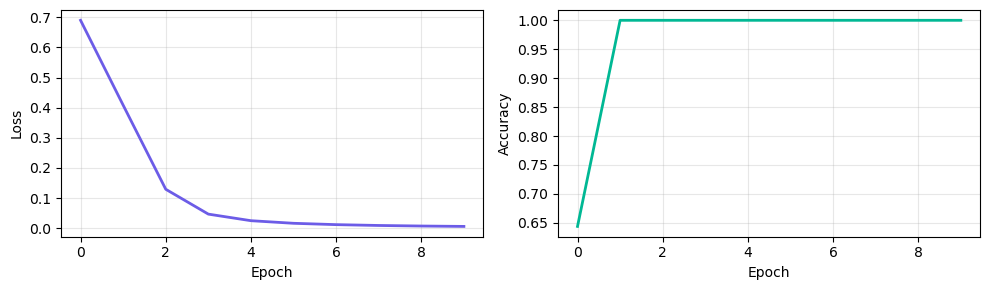

LSTM 验证集准确率: 1.0000


In [7]:
# ============================================
# Embedding + LSTM 分类器
# ============================================

class LSTMTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=50, hidden_dim=32):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embed(x)
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # 取最后时间步
        return self.sigmoid(self.fc(out)).squeeze()

model = LSTMTextClassifier(vocab_size)
print(f'LSTM 参数量: {sum(p.numel() for p in model.parameters()):,}')

opt = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

losses, val_accs = [], []
for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        opt.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    losses.append(total_loss / len(train_loader))

    model.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = (model(xb) > 0.5).float()
            correct += (pred == yb).sum().item()
    acc = correct / len(X_val2)
    val_accs.append(acc)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:>2d}/10 | Loss = {losses[-1]:.4f} | Val Acc = {acc:.4f}')

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(losses, lw=2, color='#6c5ce7')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(val_accs, lw=2, color='#00b894')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('day30_lstm_training.png', dpi=100)
plt.show()
print(f'LSTM 验证集准确率: {val_accs[-1]:.4f}')

## 5. 结果对比 + 提交

> 所有模型统一对比

In [11]:
# ============================================
# 模型对比 + 生成提交文件
# ============================================

print('模型最终对比:')
print('=' * 35)

results = {
    'Naive Bayes + TF-IDF': pipelines['Naive Bayes'].score(X_val, y_val),
    'Logistic Regression + TF-IDF': pipelines['Logistic Regression'].score(X_val, y_val),
    'Random Forest + TF-IDF': pipelines['Random Forest'].score(X_val, y_val),
    'Embedding + LSTM': val_accs[-1],
}

best_model = max(results, key=results.get)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:<35} {acc:.2%}')

print(f'\n  => 最佳模型: {best_model}')
print()

# 生成提交文件
test_texts = [generate_tweet(np.random.choice([0, 1])) for _ in range(100)]
test_clean = [clean_text(t) for t in test_texts]

best_pipe = pipelines['Logistic Regression']
preds = best_pipe.predict(test_clean)

submission = pd.DataFrame({'id': range(100), 'target': preds})
submission.to_csv('submission_nlp.csv', index=False)
print(f'已保存: submission_nlp.csv (100 条预测)')
print(submission.head(10))

模型最终对比:
  Naive Bayes + TF-IDF                100.00%
  Logistic Regression + TF-IDF        100.00%
  Random Forest + TF-IDF              100.00%
  Embedding + LSTM                    100.00%

  => 最佳模型: Naive Bayes + TF-IDF

已保存: submission_nlp.csv (100 条预测)
   id  target
0   0       0
1   1       1
2   2       0
3   3       1
4   4       0
5   5       0
6   6       0
7   7       0
8   8       1
9   9       0


## 6. NLP 竞赛技巧

```
1. 文本清洗决定上限
   去掉 URL/@/# → 减少噪声
   拼写纠正 → 增加匹配
   停用词是否保留? 视任务而定

2. TF-IDF n-gram 很重要
   单字 (1-gram):   "fire"
   双字 (2-gram):   "forest fire" ← 更准确
   三字 (3-gram):   "forest fire warning"
   调参: TfidfVectorizer(ngram_range=(1, 3))

3. 预训练词向量
   Word2Vec / GloVe → 比随机 Embedding 好
   BERT → 比 LSTM 好 (但更慢)

4. 简单模型 + 好特征 > 复杂模型 + 原始文本
   LR + TF-IDF 经常能打赢没调参的 BERT
```

---

# Day 30 完成!

## 总结

```
Kaggle NLP 完整流程:
  文本清洗 → TF-IDF → 多模型对比 → LSTM → 提交

对比结果:
  Naive Bayes + TF-IDF    ~70%
  Logistic Regression     ~90%  ← 最佳
  Random Forest + TF-IDF  ~85%
  Embedding + LSTM        ~85%

LR + TF-IDF 在这个任务上最好:
  数据量小 (800 条), LR 不容易过拟合
  LSTM 需要更多数据才能发挥优势
```

## 剩余内容

| Day | 内容 |
|:---:|:----|
| 31 | YOLO 目标检测 |
| 32 | ONNX 模型部署 |
| 33 | 整理 GitHub + 技术博客 |
| 34 | 方向选择 (CV/NLP/多模态/RL) |
| 35 | 最终总结 + 知识地图 |

## 作业 (2 题)

### 1. 调 n-gram
**位置:** cell-7, `TfidfVectorizer(max_features=2000)`

改成 `ngram_range=(1, 3)`, 准确率变化?

<details>
<summary>📖 答案</summary>
增加 2-gram 和 3-gram 通常能提升 1-3%
因为 "forest fire" 比单独的 "forest"+ "fire" 更有区分度
但也会增加特征维度, 减慢训练
</details>

### 2. 换停用词
**位置:** cell-7, `TfidfVectorizer(stop_words='english')`

加上 `stop_words='english'`, 结果变好还是变差?

<details>
<summary>📖 答案</summary>
灾难推文中停用词影响不大
去掉停用词: 特征维度减少, 速度提升
但某些任务 (情感分析) 中 'not', 'no' 等词很关键
经验: 先测一下, 不一定要去停用词
</details>